# ETFs: what trees can find that a penalty cannot, and what they give up to look

[`06_linear`](06_linear.ipynb) is the one place in these case studies where the linear grid
worked. Ridge at a very large penalty ranked the 99 funds well ahead of zero across the full
validation period, and the shape of that sweep said why: the feature set is **collinear**,
several columns carry nearly the same information, and a dense penalty that spreads weight
across a group of near-duplicates recovers signal that an unregularized fit buries in
offsetting coefficients.

That result frames the question for gradient boosting differently than it would be framed on a
case study where the linear model found nothing. There is a working baseline here, boosting has
to beat it, and the two properties that decide whether it can pull in opposite directions.

**In its favour, trees represent interactions a linear model cannot.** A linear model sees an
interaction only if someone multiplied two columns together and named the product. A tree splits
on one feature inside a region already defined by others, so an interaction is something it
discovers rather than something it is handed. The one this case study has a reason to expect is
the market-stress regime probability from
[`04_model_based_features`](04_model_based_features.ipynb): momentum worth following in a calm
regime may be worth fading in a stressed one, and no single coefficient on momentum expresses
both.

**Against it, collinearity is hostile to trees in a way it is not to ridge.** Faced with several
near-identical columns, a tree picks one of them at each split, and which one is close to
arbitrary. Ridge's advantage on this data came precisely from *not* choosing - from spreading
weight over the correlated group and averaging their noise down. A greedy splitter makes that
choice at every split and remakes it independently on every fold. The same property of the
feature set that made a dense penalty the right answer makes boosting an awkward fit for it.

Three dials control how far the fit goes, and this notebook varies all three:

- **Capacity**, set by `num_leaves`: how many regions one tree may carve the feature space into.
  Seven leaves can express a handful of conditions; 63 can express a partition fine enough to
  describe the training window and nothing beyond it. On a cross-section of 99 funds the top of
  this axis is in the grid as a failure case as much as a candidate.
- **The loss function**, which decides what "got wrong" means. `mse` minimizes squared error,
  `mae` absolute error, and `huber` behaves like squared error for small residuals and like
  absolute error past a threshold derived from each fold's own label spread.
- **When to stop**, set by the number of trees. Unlike a linear fit, a boosted model has a
  meaningful state at every iteration, so each configuration is scored at ten points along its
  own training run rather than only at the end.

The third dial changes how the results must be read. **A checkpoint is part of a configuration,
not a detail of how it was fitted.** Scoring 15 declared configurations at ten checkpoints each
produces 150 candidate models, and treating that as 15 candidates while quietly keeping each
one's best iteration would be reporting the maximum of ten numbers as though it were one.

**Learning objectives.** By the end of this notebook you will be able to:

- Say what a tree ensemble can represent that a penalized linear model cannot, and what a
  collinear feature set costs a greedy splitter.
- Explain why a boosted model produces one result per checkpoint while a linear model produces
  one result in total, and what that implies for counting candidates.
- Read a learning curve of out-of-sample information coefficient against tree count, and tell
  apart a model still learning from one that has begun fitting the training window.
- Say why the choice of loss function is a statement about the label's tails, and relate that to
  what a rank-based metric rewards.
- Recognise that picking each configuration's best checkpoint after seeing the results is a
  selection decision, and locate where selection is actually made.

**Book reference**: Chapter 12, Section 12.2 (GBM libraries) and Section 12.3 (how to tune a
boosted model). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run
log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) fitted the linear population this one is compared against.

**What it writes**: one training run per configuration and one complete validation prediction
set per configuration and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`14_backtest`](14_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared ETF gradient boosting population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABEL = "fwd_ret_21d"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = "etfs-gbm-validation-v1"

In [3]:
study = open_study("etfs", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which label, and which models

The label is the one the linear notebook used: `fwd_ret_21d`, the total return over the 21
trading days after the decision date. Keeping it fixed is what makes the two populations
comparable - the families differ, the target does not. The case study declares `fwd_ret_5d` as a
variant, and each label carries its own training menu at `config/training/{label}.yaml`, so
changing `LABEL` above changes which menu is read.

In [4]:
declared_labels(study, "gbm")

('fwd_ret_21d', 'fwd_ret_5d')

The menu lists 15 named configurations under `gbm:`, and each resolves to a preset in
`case_studies/config/lgb/`. The grid is a product of two axes:

- **Five capacity profiles.** `default` uses the library's own leaf count; the rest fix it at 7,
  15, 31 and 63.
- **Three objectives**, as described above.

Every configuration runs the same number of boosting iterations at the same learning rate, so
the grid isolates capacity and loss rather than confounding them with training length.

In [5]:
configs = load_model_configs(
    study,
    "gbm",
    labels=[LABEL],
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""gbm""","""fwd_ret_21d""","""default_mse""","""""","""objective=regression, seed=42"""
"""gbm""","""fwd_ret_21d""","""default_mae""","""""","""objective=regression_l1, seed=…"
"""gbm""","""fwd_ret_21d""","""default_huber""","""""","""objective=huber, seed=42"""
"""gbm""","""fwd_ret_21d""","""leaves_7_mse""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_21d""","""leaves_7_mae""","""""","""bagging_fraction=0.8, bagging_…"
…,…,…,…,…
"""gbm""","""fwd_ret_21d""","""leaves_31_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_21d""","""leaves_31_huber""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_21d""","""leaves_63_mse""","""""","""bagging_fraction=0.8, bagging_…"


## 2. Binding the declarations to the data

Resolving reads the label and feature files, computes the fold boundaries, works out the exact
rows each fit must predict, and turns any data-dependent parameter into the number it will use.
Huber's threshold is one of those: it is a fraction of the training labels' standard deviation,
so it is a different number on every fold and is resolved from that fold's own data.

Nothing is fitted here, so the plan can be inspected first. Four things to check:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** A row
  that differs is a configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is where this differs from the linear plan.** It is the number of training
  states each configuration will publish predictions for. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

In [6]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,i64,i64,i64,i64,i64,date,date
"""default_huber""",71,99,188473,8,10,2015-12-28,2023-11-29
"""default_mae""",71,99,188473,8,10,2015-12-28,2023-11-29
"""default_mse""",71,99,188473,8,10,2015-12-28,2023-11-29
"""leaves_15_huber""",71,99,188473,8,10,2015-12-28,2023-11-29
"""leaves_15_mae""",71,99,188473,8,10,2015-12-28,2023-11-29
…,…,…,…,…,…,…,…
"""leaves_63_mae""",71,99,188473,8,10,2015-12-28,2023-11-29
"""leaves_63_mse""",71,99,188473,8,10,2015-12-28,2023-11-29
"""leaves_7_huber""",71,99,188473,8,10,2015-12-28,2023-11-29


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. casts the design matrix to the precision LightGBM works in and leaves missing values in
   place - a tree routes a missing value down its own branch, so imputing a median here would
   hand the model an observation nobody made,
3. fits the declared number of boosting iterations,
4. predicts the fold's validation rows at each checkpoint, using only the trees built up to that
   iteration.

Step 4 is what makes one fit produce many results. The fold predictions are concatenated into
one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

Preparation happens once per fold and is shared by every configuration, because slicing the
window and cleaning the rows depends on the data and not on the model. The run walks folds on
the outside and configurations on the inside for the same reason: one prepared fold is held at a
time rather than the whole set.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [7]:
execution, population = run_model_population(study, resolved, population_name=POPULATION_NAME)

print(f"{len(execution.runs)} configurations fitted")
print(f"population {population.name}: {len(population.members)} prediction sets")

15 configurations fitted
population etfs-gbm-validation-v1: 150 prediction sets


Re-running this notebook unchanged costs the time it takes to read the data. Every identity is
re-derived from the inputs, the registry already holds the matching rows, and the runner returns
the stored result rather than fitting again.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("etfs", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "gbm", labels=["fwd_ret_21d"], config_names=["leaves_15_huber", "leaves_31_huber"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-gbm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu declares. To fit something new, add a preset at
`case_studies/config/lgb/leaves_127_huber.yaml` and list `leaves_127_huber` under `gbm:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per configuration and checkpoint. `ic_mean` is the **information coefficient**: on each
validation date, rank the funds by the model's prediction, rank them by the return they went on
to earn, correlate the two rankings, and average that daily correlation over the validation
period.

The table is sorted by IC, and the top of it is the trap this notebook exists to describe. The
leading row is the maximum of 150 numbers. Reading it as the result of one experiment would
attribute to the model whatever the stopping point contributed, and the section below measures
how large that contribution is before anything is concluded from the ranking.

`ic_n_days` carries the second warning, and it is the one `06_linear` turned on: a configuration
that scored fewer dates than its neighbours is not comparable to them, because its IC is an
average over the dates where it stayed non-degenerate. Every comparison below is restricted to
full-coverage members for that reason.

In [8]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("ic_mean", descending=True)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("gbm execution returned a partial prediction set")

full_days = int(catalog.get_column("ic_n_days").max())
catalog = catalog.with_columns(full_coverage=pl.col("ic_n_days") == full_days)

print(f"{catalog.height} candidate models: {catalog.n_unique('config_name')} configurations")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each")
catalog.select(
    "config_name",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(15)

150 candidate models: 15 configurations
at 10 checkpoints each


config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,i64,f64,f64,f64,bool
"""leaves_7_huber""",100,0.066087,0.063954,1995.0,true
"""leaves_31_huber""",100,0.060478,0.067757,1995.0,true
"""leaves_63_huber""",50,0.05934,0.078595,1995.0,true
"""leaves_15_huber""",100,0.059324,0.069232,1995.0,true
"""leaves_7_huber""",150,0.058188,0.060671,1995.0,true
…,…,…,…,…,…
"""leaves_15_mse""",50,0.052103,0.044734,1995.0,true
"""leaves_15_huber""",50,0.050074,0.060998,1995.0,true
"""leaves_15_huber""",200,0.049474,0.052553,1995.0,true


### What more trees do

Each line traces one configuration's out-of-sample IC as trees are added to it. This is the
figure the checkpoint dimension exists to produce, and it separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
without trend around zero never had anything to learn in the first place, and its highest point
is wherever the noise happened to peak. The difference matters, because both produce a
respectable-looking maximum.

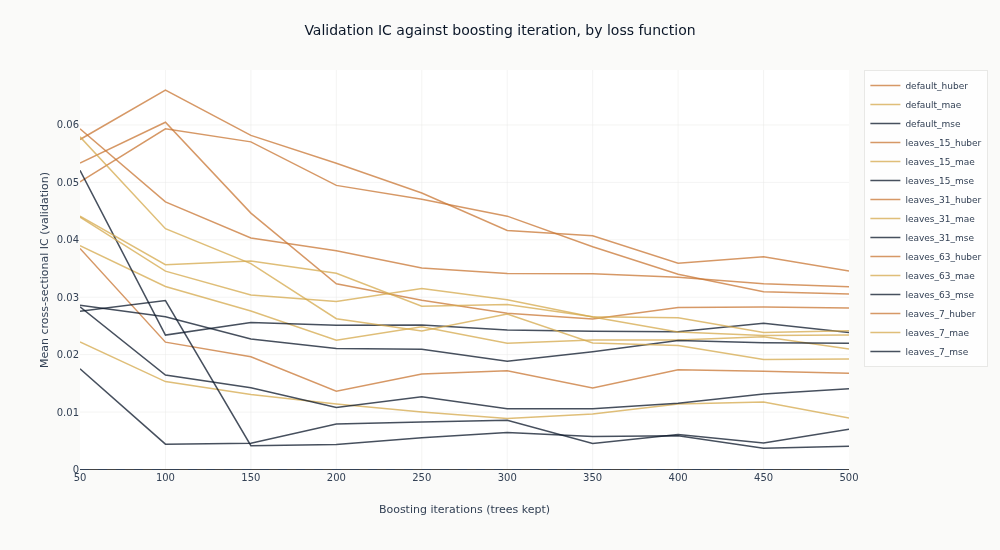

In [9]:
curves = catalog.filter("full_coverage").sort("config_name", "checkpoint_value")
objectives = {"mse": COLORS["blue"], "mae": COLORS["amber"], "huber": COLORS["copper"]}


def objective_of(name: str) -> str:
    """Read the loss function out of a declared configuration name."""
    return next((key for key in objectives if name.endswith(key)), "mse")


fig_curves = go.Figure()
for config_name in curves.get_column("config_name").unique(maintain_order=True):
    series = curves.filter(pl.col("config_name") == config_name)
    fig_curves.add_trace(
        go.Scatter(
            x=series.get_column("checkpoint_value").to_list(),
            y=series.get_column("ic_mean").to_list(),
            mode="lines",
            name=config_name,
            line=dict(color=objectives[objective_of(config_name)], width=1.5),
            opacity=0.75,
        )
    )
fig_curves.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_curves.update_layout(
    title="Validation IC against boosting iteration, by loss function",
    height=550,
    width=1000,
    margin=dict(t=70),
    legend=dict(font=dict(size=9)),
)
fig_curves.update_xaxes(title_text="Boosting iterations (trees kept)")
fig_curves.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_curves,
    "Line chart of mean validation information coefficient against boosting iteration, one line "
    "per configuration, coloured by loss function: blue for squared error, amber for absolute "
    "error, copper for Huber. A dashed line marks zero. Every line stays above zero across the "
    "whole range. All fifteen rise to their highest point at the first or second checkpoint and "
    "decline steadily from there, so the curves share one shape and the declared training length "
    "runs well past every peak. The copper Huber lines sit above the others over most of the "
    "range and the blue squared-error lines are lowest at the right-hand end.",
)

### Whether the loss function is what separates them

The curves are coloured by objective because that is the axis with a mechanism behind it. If
heavy tails are steering the squared-error fits, the three colours should separate, and they
should separate more as trees are added, since each additional tree is fitted to the residuals
the previous ones left.

The chart below drops the checkpoint dimension by taking each configuration's final state, so
every configuration is compared at the same amount of training. That is the comparison that does
not require choosing anything after the fact.

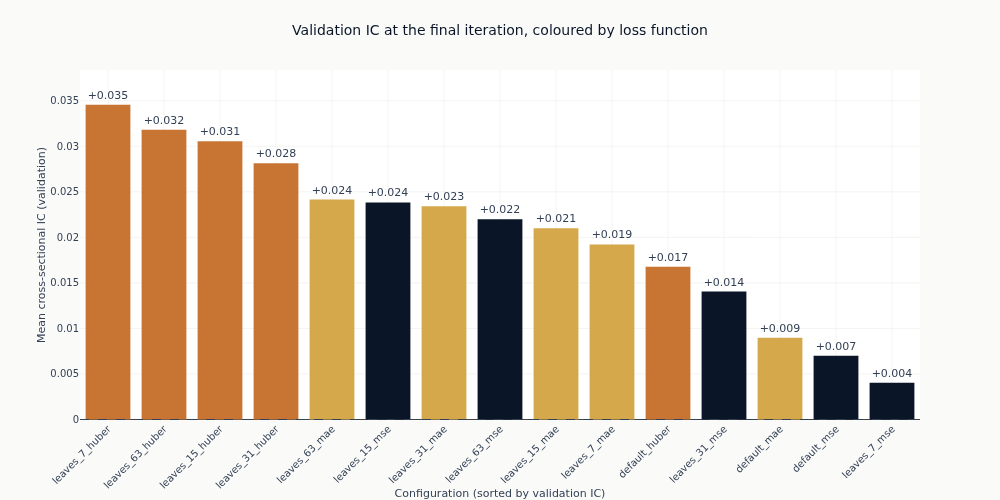

In [10]:
final_iteration = int(catalog.get_column("checkpoint_value").max())
final = (
    catalog.filter(pl.col("checkpoint_value") == final_iteration)
    .filter("full_coverage")
    .with_columns(objective=pl.col("config_name").map_elements(objective_of, return_dtype=pl.Utf8))
    .sort("ic_mean", descending=True)
)

fig_obj = go.Figure(
    go.Bar(
        x=final.get_column("config_name").to_list(),
        y=final.get_column("ic_mean").to_list(),
        marker_color=[objectives[value] for value in final.get_column("objective")],
        text=[f"{value:+.3f}" for value in final.get_column("ic_mean")],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_obj.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_obj.update_layout(
    title="Validation IC at the final iteration, coloured by loss function",
    height=500,
    width=1000,
    showlegend=False,
    margin=dict(t=70),
)
fig_obj.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_obj.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_obj,
    "Bar chart of mean validation information coefficient for every full-coverage configuration "
    "at its final boosting iteration, sorted descending and coloured by loss function, against a "
    "dashed zero line. All fifteen bars are above the line. The four leftmost are copper Huber "
    "configurations with fixed leaf counts, so Huber's weakest fixed-capacity setting still "
    "outranks every absolute-error and squared-error one. Amber absolute-error and blue "
    "squared-error bars are interleaved through the middle of the ranking, and the two shortest "
    "bars are both squared-error configurations. The three library-default capacity settings sit "
    "low whichever objective they are paired with.",
)

### How much the checkpoint moves a configuration

One number per configuration: the range its IC covers across its own ten checkpoints. This is
the quantity that decides whether choosing a stopping point is a decision worth making carefully
or one being made by noise. A configuration whose IC varies more across its own training run
than the configurations vary among themselves is one where the checkpoint, not the model, is
doing the ranking.

In [11]:
spread = (
    curves.group_by("config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").filter(pl.col("checkpoint_value") == final_iteration).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort("checkpoint_range", descending=True)
)
across_configs = float(final.get_column("ic_mean").max() - final.get_column("ic_mean").min())
print(f"IC range across configurations at the final iteration: {across_configs:.4f}")
print(
    f"median IC range within one configuration: {spread.get_column('checkpoint_range').median():.4f}"
)
spread

IC range across configurations at the final iteration: 0.0305
median IC range within one configuration: 0.0249


config_name,ic_min,ic_max,ic_final,checkpoint_range
str,f64,f64,f64,f64
"""leaves_7_mae""",0.019154,0.057938,0.019223,0.038784
"""leaves_31_huber""",0.02619,0.060478,0.028137,0.034288
"""leaves_7_huber""",0.034555,0.066087,0.034555,0.031531
"""leaves_15_huber""",0.030543,0.059324,0.030543,0.02878
"""leaves_15_mse""",0.023408,0.052103,0.023839,0.028695
…,…,…,…,…
"""leaves_15_mae""",0.021002,0.038996,0.021002,0.017994
"""leaves_31_mse""",0.010576,0.028317,0.014046,0.017741
"""default_mae""",0.008872,0.022219,0.008968,0.013346


## 5. What to notice

**Every configuration ranks the cross-section the right way, and the loss function orders them.**
All fifteen are positive at the end of training. Sorted by IC, the four fixed-capacity Huber
configurations take the top four places, absolute error follows, and squared error occupies the
bottom - the weakest Huber setting still ranks above the strongest absolute-error one. That is
the order the label's tails predict. Squared error weights an observation by the square of its
error, so the largest 21-day moves dominate what each successive tree is fitted to, while the
information coefficient is a rank correlation that cares about order rather than magnitude:
effort spent getting the extremes right buys nothing on this metric. **An objective is a claim
about which errors matter, and it is worth choosing to match the metric the result will be
judged on.**

**The boosted population does not beat the linear one.** The strongest full-coverage
configuration here ranks below the strongest full-coverage configuration in
[`06_linear`](06_linear.ipynb), on the same label, the same features and the same folds. This is
the outcome the collinearity argument at the top of this notebook implies, and it is worth
taking seriously rather than treating as a tuning failure. Ridge earned its result by refusing
to choose among near-duplicate columns - spreading weight across a correlated group averages
their noise down. A tree chooses one column at every split, and remakes that choice
independently on every fold, which is the opposite operation on the same feature set. The
interactions the trees can represent and a linear model cannot are real, but on this data they
do not pay for what greedy splitting gives up.

**Every configuration is past its peak by the time it is reported.** All fifteen reach their
highest validation IC at the first or the second checkpoint and decline from there, without
exception. So the declared training length is longer than this data supports, and the
fixed-iteration comparison above is a comparison of fifteen models in their overfitted regime.
That comparison is still the honest one, because each configuration is measured at the same
amount of training and nothing is chosen after the fact - but the ranking it produces is not the
ranking their best states would produce, and neither is a result until something selects on a
criterion that was fixed in advance.

**The checkpoint is nearly as large a dial as the model.** Across the fifteen configurations at
fixed training length the IC spans a range; within a single configuration, across its own ten
checkpoints, the median range is about four fifths of that. A stopping point chosen after seeing
the curves would therefore be doing almost as much work as the choice of model, which is why
reporting the leading row of the results table would be reporting the maximum of 150 numbers as
though it were one.

**None of this selects anything.** IC measures whether predictions rank funds correctly, not
whether a strategy trading them makes money after costs and turnover. A monthly-horizon signal
that reorders the portfolio at every rebalance is exactly where a small ranking advantage is
lost. Selection is on validation backtest Sharpe over the population just published, and it
happens in [`14_backtest`](14_backtest.ipynb), where the checkpoint is part of what is selected.

**Known limitations.** The IC is an average of daily rank correlations with no adjustment for
the serial dependence overlapping 21-day returns create, so it is a diagnostic rather than a
test, and it carries no interval that would say whether these configurations differ from each
other or from the linear ones. The grid varies capacity and loss at a fixed learning rate and a
fixed training length, so it says nothing about trading one against another - and the previous
point is the reason that matters here. And every number is measured on validation folds that
have been read many times over by the time a case study reaches this notebook.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) asks the same question of a neural network
built for tabular data, which represents interactions in a third way again. The useful thing to
watch there is whether it recovers whatever structure the trees found here, and whether a
collinear feature set costs it what it costs a greedy splitter.